In [1]:
import pandas as pd
df = pd.read_csv("qr_fraud_detection_dataset_10000.csv")

In [2]:
x = df.drop('Fraud', axis=1)
y = df['Fraud']

In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
x_train = pd.get_dummies(x_train)
x_test = pd.get_dummies(x_test)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 17)
(2000, 17)
(8000,)
(2000,)


In [4]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
from sklearn.metrics import classification_report
y_pred = rf.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00      1800

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [6]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 200    0]
 [   0 1800]]


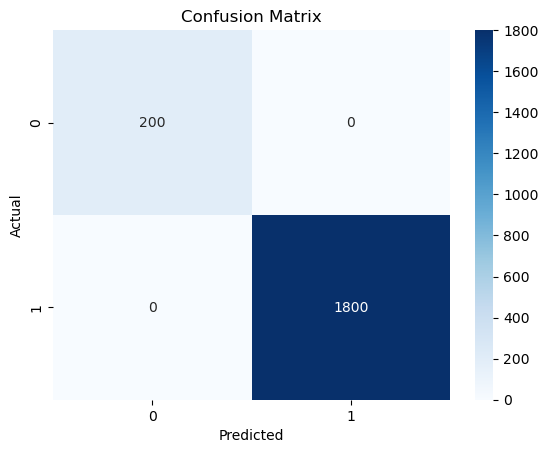

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [8]:
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(by='Importance', ascending=False)
print(importance.head(10))

                   Feature  Importance
5          Domain_Age_Days    0.388900
0               URL_Length    0.242245
1                    HTTPS    0.154054
6              Blacklisted    0.121905
11   Domain_Extension_info    0.023215
7   Domain_Extension_click    0.019481
14   Domain_Extension_site    0.018203
16    Domain_Extension_xyz    0.014289
15    Domain_Extension_top    0.013969
3    Contains_Verification    0.002432
